**Imports Library And setup **

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

Load Data

In [14]:
df = pd.read_csv("/content/tested.csv")  # update path if needed
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Data Cleaning

In [15]:
# Fill missing Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin due to many missing values
df.drop(columns=['Cabin'], inplace=True)

# Check missing values
df.isnull().sum()

/tmp/ipykernel_12776/3346362093.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_12776/3346362093.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,1


Feature Engineering

In [16]:
# Family size
df['FamilySize'] = df['SibSp'] + df['Parch']

# Age groups
df['AgeGroup'] = pd.cut(df['Age'],
bins=[0,12,20,40,60,80],
labels=['Child','Teen','Adult','MidAge','Senior'])

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,0,Adult
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,1,MidAge
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,0,Senior
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,0,Adult
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,2,Adult


Visualizations





1. Histogram — Age Distribution

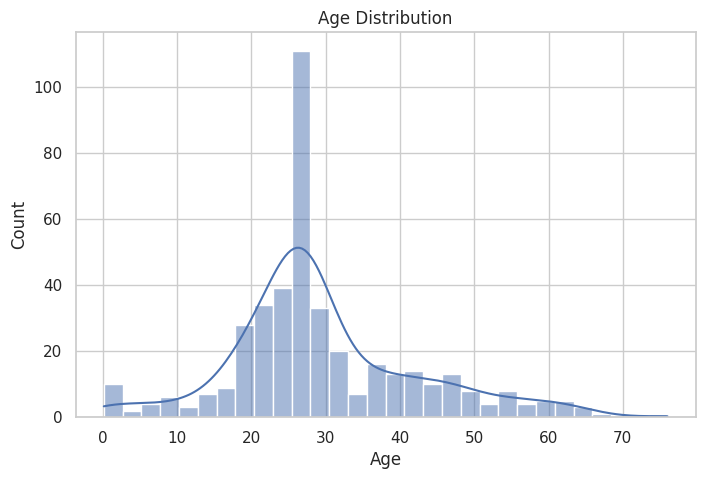

In [17]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

2.Bar Chart — Survival by Sex

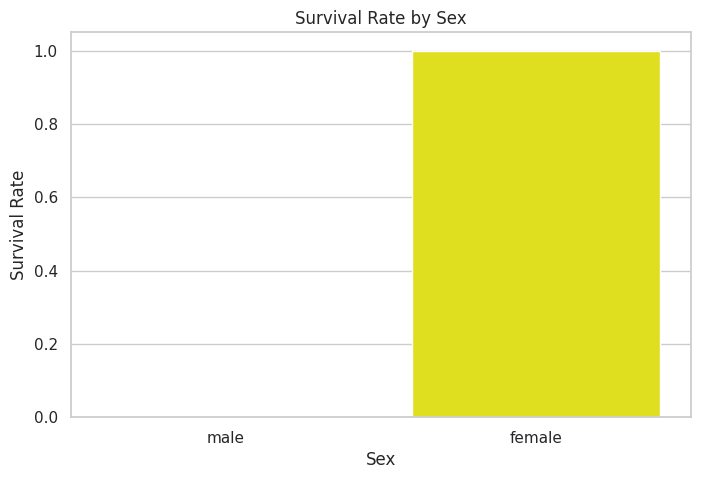

In [18]:
sns.barplot(x='Sex', y='Survived', color="yellow", data=df)
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

3. Bar Chart — Survival by Class

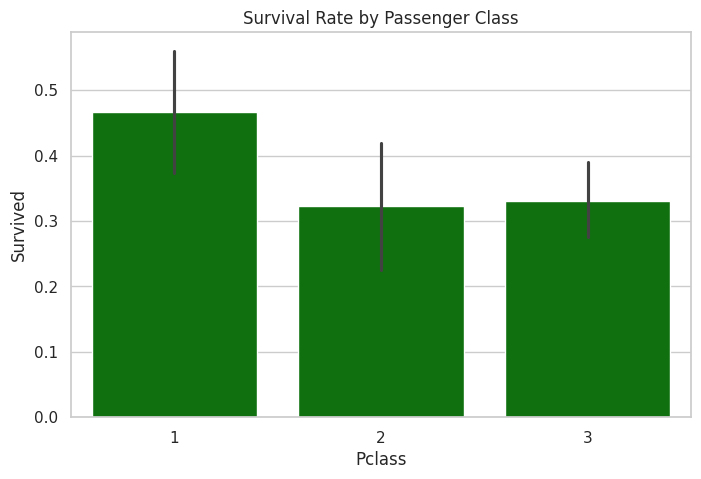

In [19]:
sns.barplot(x='Pclass', y='Survived',color="green", data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

4. Boxplot — Fare by Class

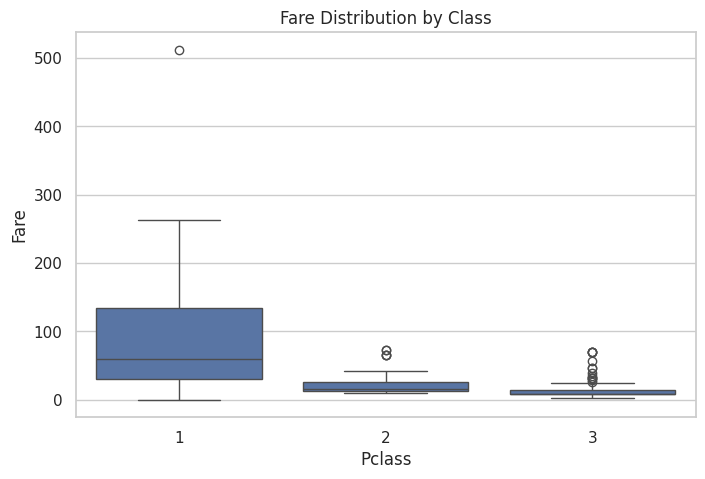

In [20]:
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Fare Distribution by Class")
plt.show()

5. Scatterplot — Age vs Fare (colored by Survival)

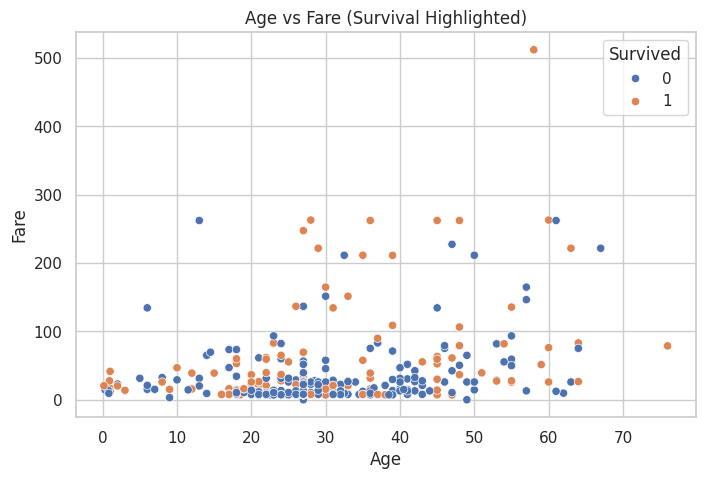

In [21]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title("Age vs Fare (Survival Highlighted)")
plt.show()

6. Heatmap — Correlation Matrix

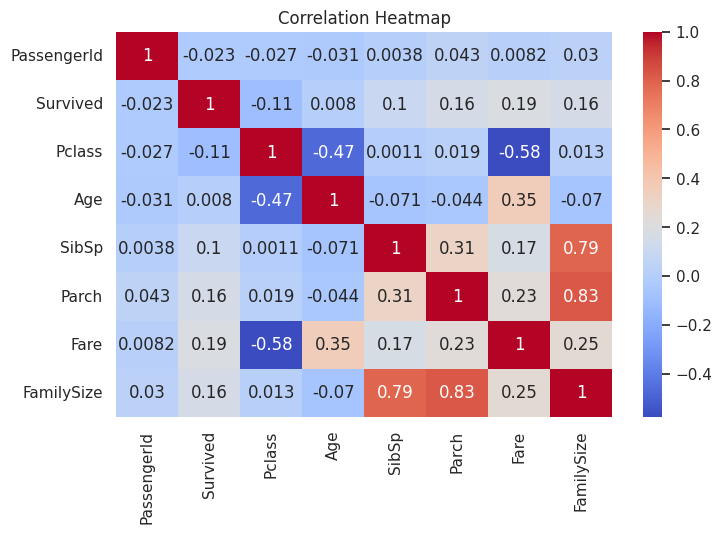

In [22]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()